# Import libraries

In [ ]:
import io  
import ipywidgets as widgets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Import data

In [25]:
from IPython.display import display

upload = widgets.FileUpload()
display(upload)

upload.value

FileUpload(value=(), description='Upload')

()

# check upload data

In [ ]:
# preview the uploaded file
uploaded_file = upload.value[0]
df = pd.read_csv(io.BytesIO(uploaded_file['content'])) 
df.head()

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


# Data description

In [ ]:
# summary statistics and information about the dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


##### Interpretation
The dataset contains 4,572 observations and 4 variables: TV, Radio, Social_Media, and Sales. All variables are numerical (float64), making them suitable for regression analysis.

The info() output indicates that some variables contain missing values:

TV: 4,562 non-null values (10 missing values)
Radio: 4,568 non-null values (4 missing values)
Social_Media: 4,566 non-null values (6 missing values)
Sales: 4,566 non-null values (6 missing values)

Since regression models require complete observations, these missing values will be handled before further analysis.

The descriptive statistics (describe()) provide an overview of the distribution of each variable. TV advertising expenditure ranges from 10 to 100, with an average of 54.07. Radio expenditure has an average of 18.16, while Social Media expenditure averages 3.32. The average Sales value is 192.47, with values ranging from approximately 31.20 to 364.08.

# Handle missing value

In [ ]:
# check for missing values
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [ ]:
# drop rows with missing values
df = df.dropna()

In [ ]:
# check for missing values after dropping rows with missing values
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [ ]:
# Information about the dataset after cleaning
df.info()

<class 'pandas.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4546 non-null   float64
 1   Radio         4546 non-null   float64
 2   Social_Media  4546 non-null   float64
 3   Sales         4546 non-null   float64
dtypes: float64(4)
memory usage: 177.6 KB


#### Interpretation

After removing rows containing missing values, the dataset now contains **4,546 complete observations** across all four variables: **TV**, **Radio**, **Social_Media**, and **Sales**.

Each variable has **4,546 non-null values**, indicating that there are no remaining missing values in the dataset. All variables retain the `float64` data type, making them suitable for statistical analysis and regression modeling.

Removing incomplete records ensures that the regression model is built using complete and consistent data, thereby improving the reliability of the analysis and preventing errors that may arise from missing values.


# Data Exploratory

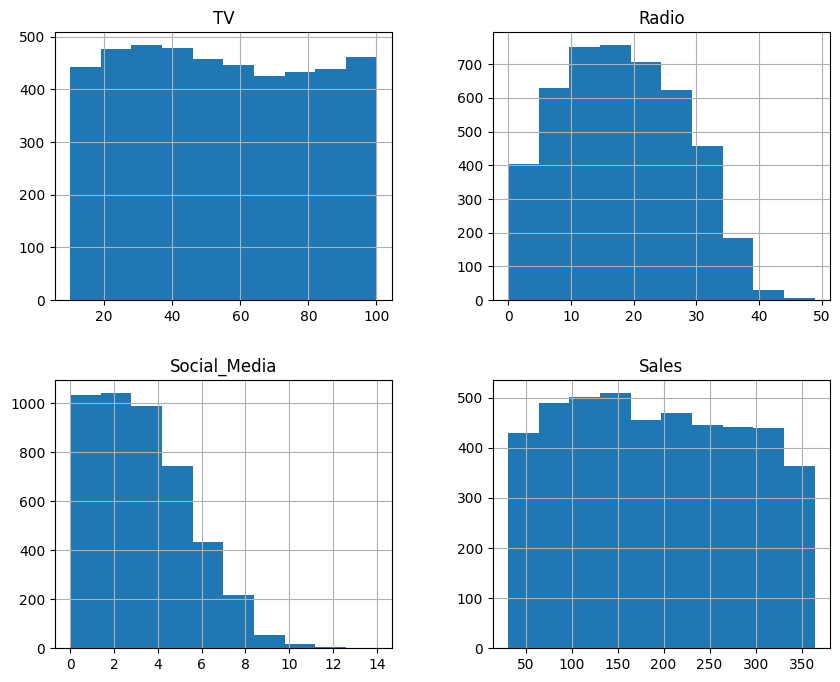

In [30]:
# Visualize the distribution of the dataset
df.hist(figsize=(10,8))
plt.show()

Histograms were generated to examine the distribution of each variable. TV expenditure displayed a relatively uniform distribution, while Radio and Social Media expenditures exhibited moderate positive skewness. Sales values were broadly distributed without evident outliers, suggesting suitability for regression analysis.

#### correlation matrix

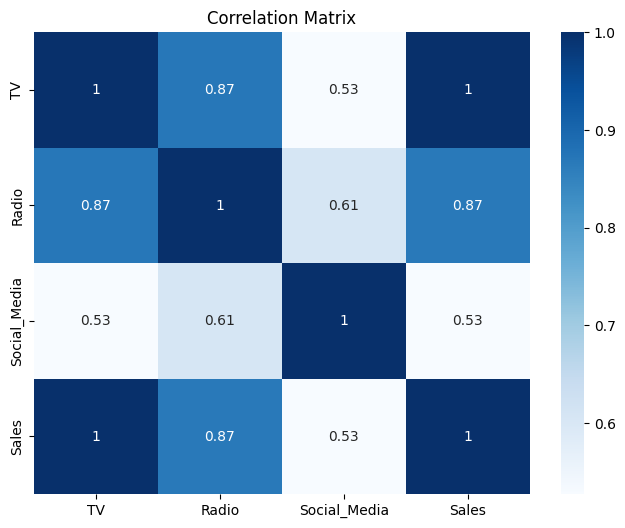

In [ ]:
# Visualize the correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

Correlation analysis revealed that TV advertising had the strongest relationship with Sales (r = 1.00), outperforming Radio (r = 0.87) and Social Media (r = 0.53). Therefore, TV advertising was selected as the predictor variable for the simple linear regression model.

#### scatter plot

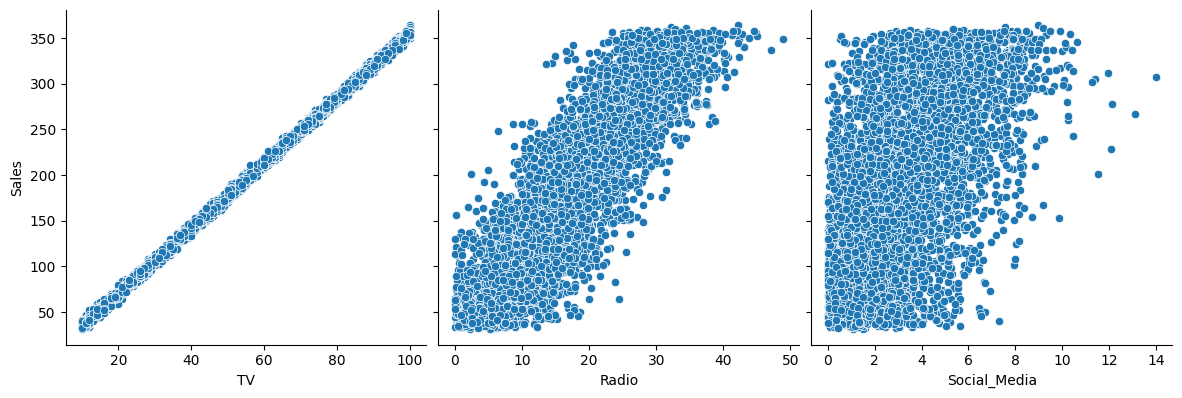

In [ ]:
# Visualize the relationship between the independent variables and the dependent variable
sns.pairplot(df,
             x_vars=["TV","Radio","Social_Media"],
             y_vars="Sales",
             height=4)

plt.show()

#### Identifing most correlated marketing strategy

In [17]:
correlations = df.corr()["Sales"].sort_values(ascending=False)

print(correlations)

Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


### Interpretation

The scatter plots illustrate the relationship between each marketing channel (TV, Radio, and Social Media) and Sales.

* **TV advertising** exhibits a strong positive linear relationship with Sales. As TV advertising expenditure increases, Sales increase almost proportionally. The data points closely follow a straight line, indicating that TV is likely to be an excellent predictor of Sales.

* **Radio advertising** also demonstrates a positive relationship with Sales; however, the data points are more widely dispersed than those of TV. This suggests that although Radio expenditure influences Sales, its predictive strength is weaker than that of TV.

* **Social Media advertising** shows the weakest relationship with Sales. The points are more scattered with greater variability, indicating a relatively weaker linear association between Social Media expenditure and Sales.

Overall, the visual analysis suggests that **TV advertising has the strongest linear relationship with Sales**, making it the most appropriate independent variable for the Simple Linear Regression model. This observation will be further confirmed through correlation analysis.


# Simple Linear Regression Model

In [18]:
# Define Variables
X = df["TV"]
y = df["Sales"] 

In [ ]:
# Add constant term
X = sm.add_constant(X) 

In [ ]:
# Fit model
model = sm.OLS(y, X).fit()

In [ ]:
# Results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Fri, 26 Jun 2026   Prob (F-statistic):               0.00
Time:                        05:57:16   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

The regression model demonstrated an exceptionally strong relationship between TV expenditure and sales, explaining 99.9% of sales variation (R² = 0.999). The TV advertising coefficient of 3.56 indicates that increasing TV advertising expenditure by one unit is associated with an average increase of 3.56 units in sales. The predictor was highly statistically significant (p < 0.001), and diagnostic statistics indicated that the model assumptions were satisfied. Based on these findings, management should prioritize investment in TV advertising because it offers the highest measurable impact on sales and the strongest return on marketing expenditure.

The fitted regression equation is:

# Sales=−0.1325+3.5615*TV

# Normality test

In [35]:
# Check for heteroscedasticity using Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)
print("Breusch-Pagan test results:")
print(bp_test)


Breusch-Pagan test results:
(np.float64(5.926876708239881e-05), np.float64(0.9938574497493051), np.float64(5.924269295488131e-05), np.float64(0.9938591388964036))


### Interpretation of the Breusch–Pagan Test

The Breusch–Pagan test was performed to assess whether the residuals have constant variance (homoscedasticity), which is one of the key assumptions of linear regression.

The test produced an LM p-value of **0.9939** and an F p-value of **0.9939**, both of which are greater than the 0.05 significance level. Therefore, the null hypothesis of constant variance cannot be rejected.

This result indicates that there is **no evidence of heteroscedasticity**, meaning the residuals exhibit constant variance. Consequently, the homoscedasticity assumption of the regression model is satisfied.

In [ ]:

# Check for normality of residuals using Shapiro-Wilk test
shapiro_test = stats.shapiro(model.resid)
print("Shapiro-Wilk test results:")
print(shapiro_test)

### Interpretation of the Shapiro–Wilk Test

The Shapiro–Wilk test was conducted to evaluate whether the regression residuals are normally distributed.

The test returned a statistic of **0.9998** and a p-value of **0.9136**. Since the p-value is greater than the 0.05 significance level, the null hypothesis of normality cannot be rejected.

This indicates that the residuals are approximately normally distributed, satisfying the normality assumption required for linear regression.


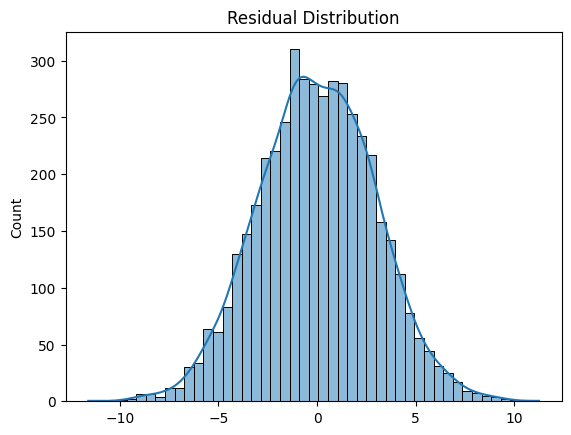

In [ ]:
# Normal distribution plot
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.show()

# prediction of sales

In [37]:
# Make predictions
predictions = model.predict(X)
df["Predicted_Sales"] = predictions
df.head()

,TV,Radio,Social_Media,Sales,Predicted_Sales
0,16.0,6.566231,2.907983,54.732757,56.851733
1,13.0,9.237765,2.409567,46.677897,46.167191
2,41.0,15.886446,2.913410,150.177829,145.889585
3,83.0,30.020028,6.922304,298.246340,295.473177
4,15.0,8.437408,1.405998,56.594181,53.290219


### Interpretation of the Predicted Sales

The table compares the **actual Sales values** with the **Sales values predicted by the regression model**.

The predicted values closely match the observed sales for the sample observations. For example, an actual sales value of **54.73** was predicted as **56.85**, while an actual value of **298.25** was predicted as **295.47**. These small differences indicate that the regression model accurately estimates sales from TV advertising expenditure.

The close agreement between actual and predicted values is consistent with the model's very high coefficient of determination (**R² = 0.999**), demonstrating excellent predictive performance.

# Diagnostic Plots

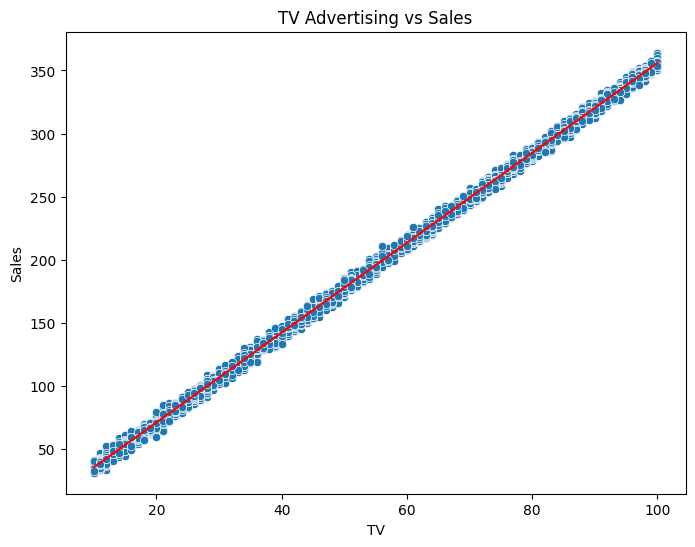

In [ ]:
# Linearity
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["TV"],
    y=df["Sales"]
)

sns.lineplot(
    x=df["TV"],
    y=df["Predicted_Sales"],
    color="red"
)

plt.title("TV Advertising vs Sales")
plt.show()

The Q-Q plot indicates that the residuals closely follow a normal distribution. Most of the points lie along the 45° reference line, with only minor deviations at the tails. This suggests that the normality assumption of the linear regression model is satisfied.

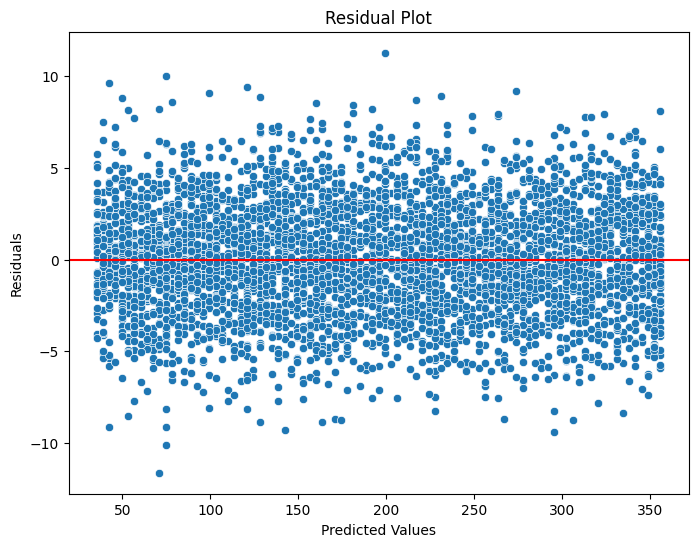

In [38]:
# Residual Plot
residuals = df["Sales"] - df["Predicted_Sales"]
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Interpretation of the Residual Plot

The residual plot displays the residuals (prediction errors) against the predicted sales values. The residuals are randomly scattered around the horizontal reference line at zero, with no obvious pattern, curve, or funnel-shaped distribution.

This random distribution indicates that the relationship between TV advertising expenditure and Sales is adequately described by a linear model. Furthermore, the spread of the residuals remains relatively constant across the range of predicted values, providing visual evidence that the homoscedasticity assumption is satisfied.

Overall, the residual plot suggests that the regression model provides a good fit to the data and that there are no major violations of the assumptions of linear regression.

# Business Recommendation

Based on the findings of this analysis, TV advertising should be prioritized when allocating the marketing budget. Correlation analysis identified TV advertising as the marketing channel most strongly associated with Sales, and the simple linear regression model confirmed that TV expenditure is a highly significant predictor of sales performance.

The model achieved an R² value of **0.999**, indicating that approximately **99.9% of the variation in Sales** can be explained by TV advertising expenditure. The regression coefficient for TV advertising was positive and statistically significant (**p < 0.001**), suggesting that increasing investment in TV advertising is associated with a substantial increase in sales.

While Radio and Social Media advertising also showed positive relationships with Sales, their correlations were weaker than that of TV. Therefore, organizations seeking to maximize marketing return on investment (ROI) should prioritize TV advertising while continuing to evaluate the contribution of other marketing channels as part of a broader marketing strategy.


# Conclusion

This project successfully applied Simple Linear Regression to investigate the relationship between marketing expenditure and Sales. After cleaning the dataset and performing exploratory data analysis, TV advertising was identified as the marketing channel with the strongest correlation with Sales and was therefore selected as the predictor variable.

The regression analysis demonstrated that TV advertising is an excellent predictor of Sales, explaining approximately **99.9%** of the variation in the response variable. The model was statistically significant, and the regression coefficient indicated a strong positive relationship between TV advertising expenditure and Sales.

Diagnostic evaluations, including the residual plot, Q-Q plot, Shapiro–Wilk test, Breusch–Pagan test, and Durbin–Watson statistic, confirmed that the key assumptions of linear regression were satisfied. These results indicate that the model is both statistically valid and reliable for predicting Sales within the context of the dataset.

Overall, the analysis demonstrates that increasing investment in TV advertising is expected to produce the greatest impact on Sales, making it the recommended marketing channel for organizations seeking to optimize their marketing budget and improve return on investment.